# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default="svg"

# Importing the Dataset

In [2]:
raw_df=pd.read_csv('Zomato Chennai.csv')

In [3]:
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# Getting basic information about the dataset

In [4]:
raw_df.shape

(12032, 12)

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
raw_df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


# Cleaning the dataset

# a. Dropping unwanted columns

In [7]:
# Checking redundunt rows of data

raw_df[raw_df.duplicated()]

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


In [8]:
# Dropping columns which are not required for further analysis
raw_df.drop(['Zomato URL', 'Address'], axis = 1, inplace=True)
raw_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


# b. Removing the null records

In [9]:
# Checking for Null records 

raw_df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

# c. Converting the DataTypes of numerical columns to numeric datatype

In [10]:
raw_df['Dining Rating Count'].value_counts()

Dining Rating Count
Does not offer Dining        2603
Not enough Dining Reviews    2528
4                             339
5                             271
6                             248
                             ... 
1267                            1
1302                            1
5073                            1
1739                            1
814                             1
Name: count, Length: 793, dtype: int64

In [11]:
# Replace text with 0 (numeric)

raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].replace(
    ['Does not offer Dining', 'Not enough Dining Reviews'], 0)

In [12]:
raw_df['Dining Rating Count'].value_counts()

Dining Rating Count
0       5131
4        339
5        271
6        248
8        180
        ... 
1302       1
5073       1
1739       1
814        1
5317       1
Name: count, Length: 792, dtype: int64

In [13]:
# Replace text with 0 (numeric)

raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].replace(
    ['Does not offer Delivery'], 0)

In [14]:
# Changing Data Type of the numerical columns

raw_df['Dining Rating Count'] = pd.to_numeric(raw_df['Dining Rating Count'], errors='coerce')
raw_df['Delivery Rating Count'] = pd.to_numeric(raw_df['Delivery Rating Count'], errors='coerce')

In [15]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          6681 non-null   float64
 6   Dining Rating Count    11812 non-null  float64
 7   Delivery Rating        6181 non-null   float64
 8   Delivery Rating Count  8433 non-null   float64
 9   Features               12032 non-null  object 
dtypes: float64(5), object(5)
memory usage: 940.1+ KB


# d. Removing the Null records

In [16]:
# Filling missing values with 0

raw_df['Dining Rating Count'].fillna(0, inplace=True)
raw_df['Delivery Rating Count'].fillna(0, inplace=True)

raw_df['Dining Rating'].fillna(0, inplace=True)
raw_df['Delivery Rating'].fillna(0, inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_26072\2998873459.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Dining Rating Count'].fillna(0, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_26072\2998873459.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [17]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          12032 non-null  float64
 6   Dining Rating Count    12032 non-null  float64
 7   Delivery Rating        12032 non-null  float64
 8   Delivery Rating Count  12032 non-null  float64
 9   Features               12032 non-null  object 
dtypes: float64(5), object(5)
memory usage: 940.1+ KB


# e. Remove brackets & quotes

In [18]:
raw_df['Cuisine'] = raw_df['Cuisine'].str.replace(r"[\[\]']", '', regex=True)
raw_df['Top Dishes'] = raw_df['Top Dishes'].str.replace(r"[\[\]']", '', regex=True)
raw_df['Features'] = raw_df['Features'].str.replace(r"[\[\]']", '', regex=True)

# Copying the cleaned data into a new DataFrame

In [19]:
zomato_df = raw_df.copy()

In [20]:
zomato_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500.0,4.3,1500.0,4.3,9306.0,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000.0,4.4,3059.0,4.1,39200.0,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500.0,4.3,1361.0,4.4,10500.0,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500.0,4.0,1101.0,4.0,11200.0,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450.0,4.2,617.0,4.1,22400.0,"Home Delivery, Indoor Seating"


# Exploratory Data Analysis

# Q1) What are the most common cuisine combinations in Chennai restaurants?

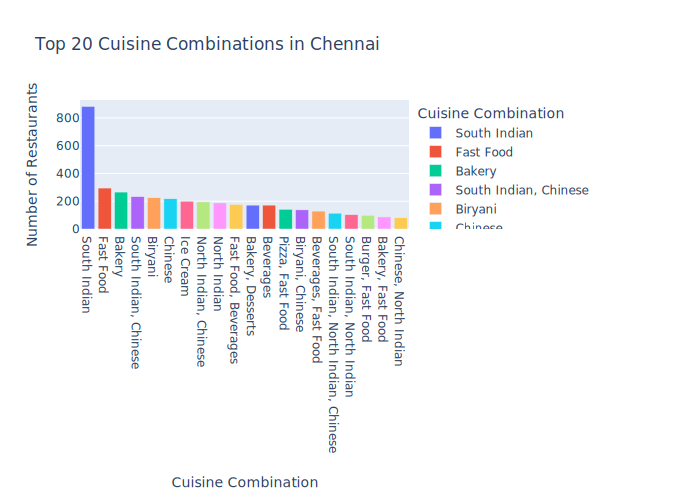

In [32]:
# Count cuisine combinations
cuisine_df = zomato_df['Cuisine'].value_counts().reset_index()
cuisine_df.columns = ['Cuisine', 'Count']

import plotly.express as px

fig = px.bar(cuisine_df.head(20),
             x='Cuisine', color='Cuisine',
             y='Count',
             title='Top 20 Cuisine Combinations in Chennai',
             labels={'Cuisine': 'Cuisine Combination', 'Count': 'Number of Restaurants'})

fig.show()

# Q2) What is the percentage distribution of restaurants based on Dining Rating?

In [66]:
zomato_df['Rating Category'] = pd.cut(
    zomato_df['Dining Rating'],
    bins=[-1, 0, 2, 3.5, 4.5, 5],
    labels=['No Rating', 'Low', 'Average', 'Good', 'Excellent']
)

rating_df = zomato_df['Rating Category'].value_counts().reset_index()
rating_df.columns = ['Rating Category', 'Count']


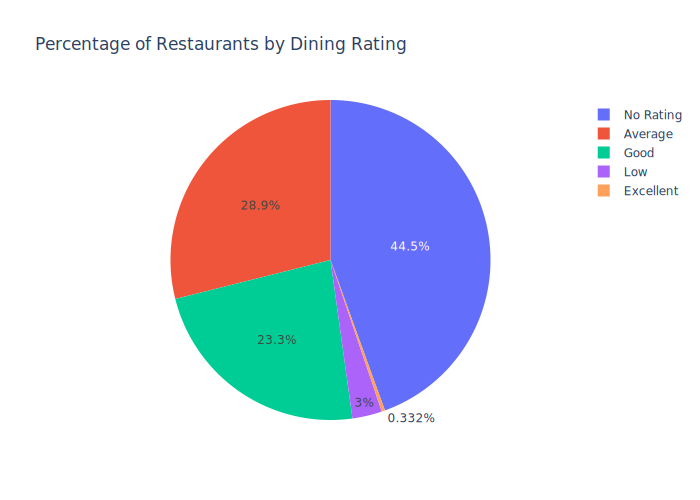

In [67]:
import plotly.express as px

fig = px.pie(rating_df,
             names='Rating Category',
             values='Count',
             title='Percentage of Restaurants by Dining Rating')

fig.show()

# Q3) Which are the Top 10 highest rated restaurants in Chennai?

In [35]:
top_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5][
    ['Name of Restaurant', 'Location', 'Dining Rating']
].sort_values(by='Dining Rating', ascending=False)

top_rated_df.head(10)

,Name of Restaurant,Location,Dining Rating
57,Brownie Heaven,Royapettah,4.9
192,Kabab Corner,Egmore,4.9
155,The Sandwich Shop,West Mambalam,4.9
105,Bhangra,"Mayajaal Multiplex, Kanathur",4.9
184,Gossip Fusion Bistro,Kanathur,4.9
219,Prems Graama Bhojanam,Adyar,4.9
320,Bombay Kulfi,Adyar,4.9
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,4.8
195,The Marina,Nungambakkam,4.8
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,4.8


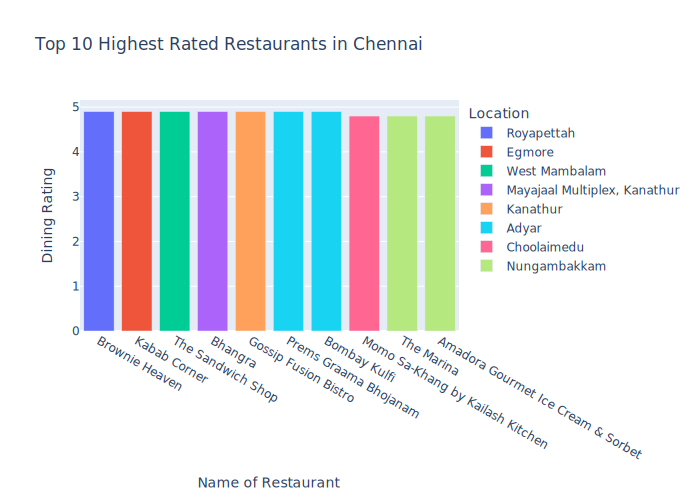

In [38]:
import plotly.express as px

fig = px.bar(top_rated_df.head(10),
             x='Name of Restaurant',
             y='Dining Rating',
             color='Location',
             title='Top 10 Highest Rated Restaurants in Chennai')

fig.show()

# Q4) Which are the highest rated restaurants that offer Delivery service?

In [41]:
delivery_df = zomato_df[zomato_df['Features'].str.contains('Home Delivery')]
top_delivery = delivery_df.sort_values(by='Dining Rating', ascending=False)[
    ['Name of Restaurant', 'Location', 'Dining Rating']
]

top_delivery.head(20)

,Name of Restaurant,Location,Dining Rating
105,Bhangra,"Mayajaal Multiplex, Kanathur",4.9
219,Prems Graama Bhojanam,Adyar,4.9
155,The Sandwich Shop,West Mambalam,4.9
184,Gossip Fusion Bistro,Kanathur,4.9
192,Kabab Corner,Egmore,4.9
320,Bombay Kulfi,Adyar,4.9
57,Brownie Heaven,Royapettah,4.9
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,4.8
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,4.8
195,The Marina,Nungambakkam,4.8


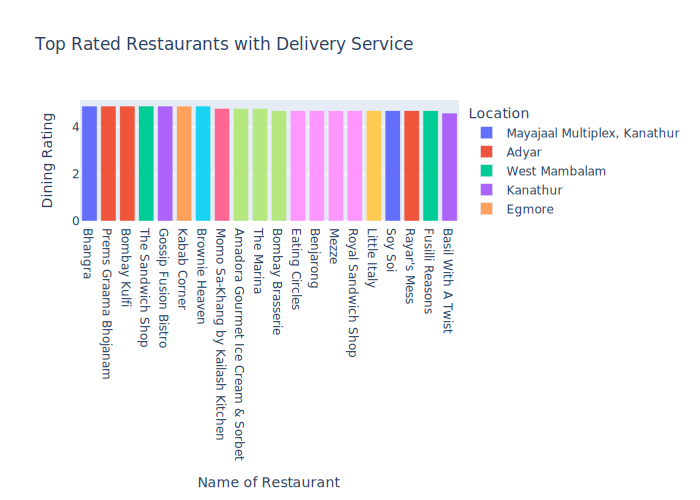

In [42]:
import plotly.express as px

fig = px.bar(top_delivery.head(20),
             x='Name of Restaurant',
             y='Dining Rating',
             color='Location',
             title='Top Rated Restaurants with Delivery Service')

fig.show()

# Q5) Which locations have the highest number of highly rated restaurants?

In [47]:
high_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5]

loc_df = high_rated_df['Location'].value_counts().reset_index()
loc_df.columns = ['Location', 'Count']

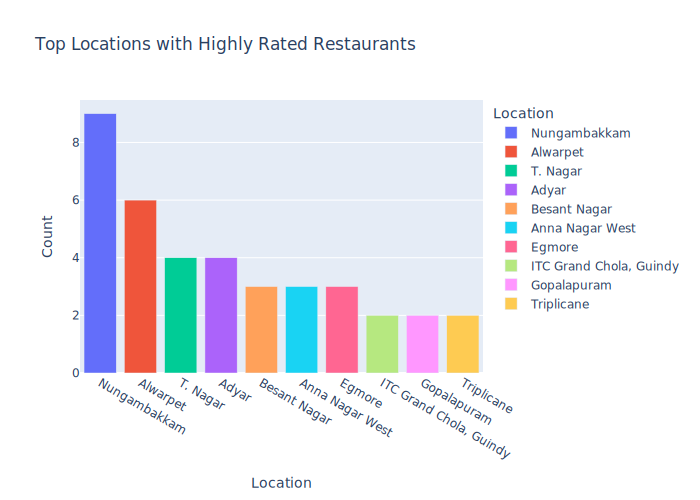

In [49]:
import plotly.express as px

fig = px.bar(loc_df.head(10),
             x='Location',color='Location',
             y='Count',
             title='Top Locations with Highly Rated Restaurants')

fig.show()

# Q6) What is the average price distribution of highly rated restaurants in Chennai?

In [50]:
high_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5]

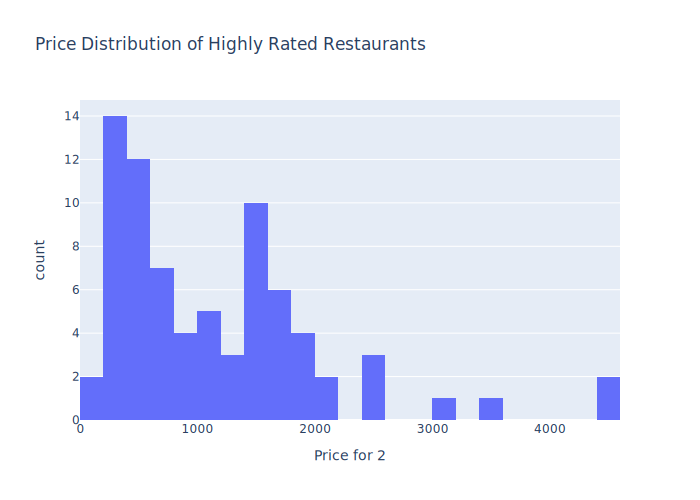

In [51]:
import plotly.express as px

fig = px.histogram(high_rated_df,
                   x='Price for 2',
                   nbins=30,
                   title='Price Distribution of Highly Rated Restaurants')

fig.show()

In [52]:
high_rated_df['Price for 2'].mean()

np.float64(1115.7894736842106)

# Q7) Which areas have a large number of Chinese restaurants in Chennai?

In [53]:
chinese_df = zomato_df[zomato_df['Cuisine'].str.contains('Chinese')]

area_df = chinese_df['Location'].value_counts().reset_index()
area_df.columns = ['Location', 'Count']

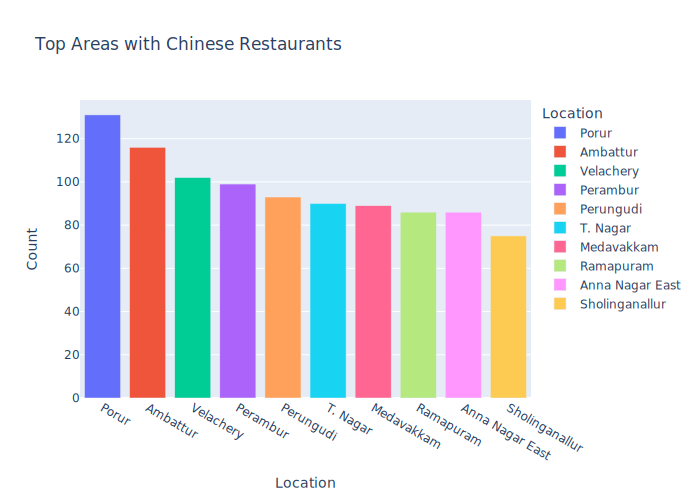

In [56]:
import plotly.express as px

fig = px.bar(area_df.head(10),
             x='Location',color='Location',
             y='Count',
             title='Top Areas with Chinese Restaurants')

fig.show()

# Q8 Is there a relationship between Price and Dining Rating?

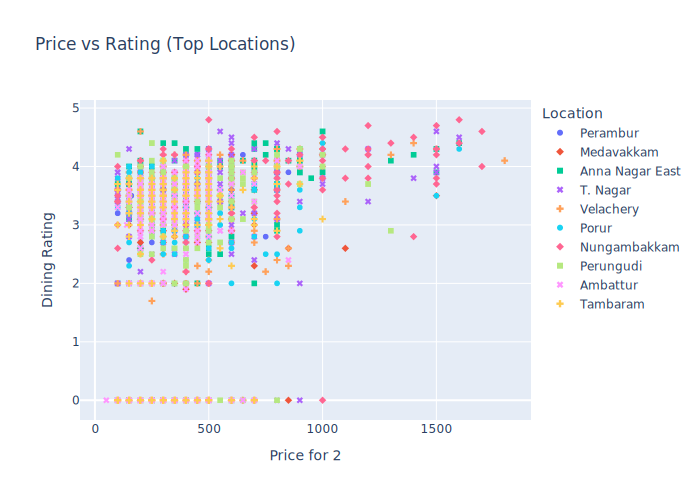

In [65]:
top_locations = zomato_df['Location'].value_counts().head(10).index

filtered_df = zomato_df[zomato_df['Location'].isin(top_locations)]

fig = px.scatter(filtered_df,
                 x='Price for 2',
                 y='Dining Rating',
                 color='Location',
                 symbol='Location',
                 title='Price vs Dining Rating (Top Locations)')

fig.update_traces(marker_size=6)

fig.show()

In [ ]:
# There is no strong relationship between price and dining rating. Both low-cost and high-cost restaurants can have high or low ratings, 
# indicating that price does not guarantee quality.

# Q9) Is there a relationship between Location and Price?

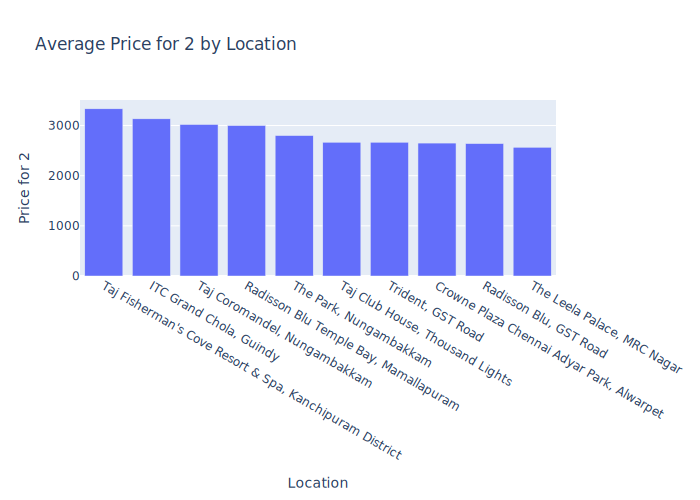

In [61]:
price_loc_df = zomato_df.groupby('Location')['Price for 2'].mean().sort_values(ascending=False).reset_index()

import plotly.express as px

fig = px.bar(price_loc_df.head(10),
             x='Location', 
             y='Price for 2',
             title='Average Price for 2 by Location')

fig.show()

# Q10) Find the list of Affordable Restaurants in Chennai

In [ ]:
# Affordable =
# Low price
# Good rating

# Conditions:
# Price for 2 < 500
# Dining Rating > 4

In [62]:
affordable_df = zomato_df[
    (zomato_df['Price for 2'] < 500) &
    (zomato_df['Dining Rating'] > 4)
][['Name of Restaurant', 'Location', 'Price for 2', 'Dining Rating']]

affordable_df.head(10)

,Name of Restaurant,Location,Price for 2,Dining Rating
4,Tasty Kitchen,Perambur,450.0,4.2
5,Dine N Fun,Medavakkam,450.0,4.1
15,Welcome Hotel,Purasavakkam,300.0,4.5
19,Malabar Biriyani Center,Aminijikarai,450.0,4.1
21,Mami Tiffen Stall,Mylapore,400.0,4.3
24,Eating Circles,Alwarpet,250.0,4.7
27,Bakya Veg Restaurant,West Mambalam,400.0,4.2
28,Midnight Madness,Adyar,450.0,4.1
32,Shri Balaajee Bhavan,Chromepet,300.0,4.3
33,Kakada Ramprasad,Kilpauk,450.0,4.3


# Q11) Find the most Reliable Restaurants

In [ ]:
#  Reliable =
# High rating
# Many reviews
# Affordable

# Conditions:
# Price for 2 < 1000
# Dining Rating > 4.5
# Dining Rating Count > 1000

In [63]:
reliable_df = zomato_df[
    (zomato_df['Price for 2'] < 1000) &
    (zomato_df['Dining Rating'] > 4.5) &
    (zomato_df['Dining Rating Count'] > 1000)
][['Name of Restaurant', 'Location', 'Price for 2', 'Dining Rating', 'Dining Rating Count']]

reliable_df

,Name of Restaurant,Location,Price for 2,Dining Rating,Dining Rating Count
37,Shree Mithai,Chetpet,300.0,4.6,1085.0
59,Mezze,Alwarpet,700.0,4.7,1152.0
62,Amadora Gourmet Ice Cream & Sorbet,Nungambakkam,500.0,4.8,1516.0
75,Fusilli Reasons,Kilpauk,400.0,4.7,3042.0
105,Bhangra,"Mayajaal Multiplex, Kanathur",800.0,4.9,2109.0
163,Momo Sa-Khang by Kailash Kitchen,Choolaimedu,350.0,4.8,1658.0
178,Royal Sandwich Shop,Alwarpet,150.0,4.7,1304.0
192,Kabab Corner,Egmore,450.0,4.9,1053.0
219,Prems Graama Bhojanam,Adyar,500.0,4.9,1511.0
